In [14]:
import pandas as pd 
import numpy as np 

In [ ]:
# main = df.read_csv('/home/monster0811/Desktop/COMPBIOUGRC/mat/Muscle_Pancreas.csv')

In [ ]:

# # Assuming `numeric_data` is your DataFrame
# n = 990  # Size of muscle block

# # Create submatrices
# muscle_to_muscle = numeric_data.iloc[:n, :n]      # Top-left block
# muscle_to_pancreas = numeric_data.iloc[:n, n:]    # Top-right block
# pancreas_to_muscle = numeric_data.iloc[n:, :n]    # Bottom-left block
# pancreas_to_pancreas = numeric_data.iloc[n:, n:]  # Bottom-right block

# # Check dimensions
# print("Muscle to Muscle:", muscle_to_muscle.shape)
# print("Muscle to Pancreas:", muscle_to_pancreas.shape)
# print("Pancreas to Muscle:", pancreas_to_muscle.shape)
# print("Pancreas to Pancreas:", pancreas_to_pancreas.shape)


In [ ]:
# muscle_to_muscle.to_csv("muscle_to_muscle.csv", index=False)

In [ ]:
# muscle_to_pancreas.to_csv("muscle_to_pancreas.csv", index=False)

In [ ]:
# pancreas_to_muscle.to_csv("pancreas_to_muscle.csv", index=False)

In [ ]:
# pancreas_to_pancreas.to_csv("pancreas_to_pancreas.csv", index=False)

In [15]:
muscle_to_muscle = pd.read_csv("muscle_to_muscle.csv")
muscle_to_pancreas = pd.read_csv("muscle_to_pancreas.csv")
pancreas_to_muscle = pd.read_csv("pancreas_to_muscle.csv")
pancreas_to_pancreas = pd.read_csv("pancreas_to_pancreas.csv")

In [16]:
import time
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt


In [17]:


# Assuming `muscle_to_muscle` is your DataFrame
# Step 1: Extract a smaller subset
subset_size = 30
test_subset = muscle_to_muscle.iloc[:subset_size, :subset_size]

# Step 2: Create a graph from the subset
G_subset = nx.from_numpy_array(test_subset.to_numpy())

# Step 3: Measure runtime for betweenness centrality calculation
start_time = time.time()

betweenness_subset = nx.betweenness_centrality(G_subset, weight='weight')

end_time = time.time()
runtime = end_time - start_time

# Step 4: Display results
print(f"Runtime for {subset_size}x{subset_size} subset: {runtime:.2f} seconds")
print("Sample betweenness centrality values:", dict(list(betweenness_subset.items())))


Runtime for 30x30 subset: 0.09 seconds
Sample betweenness centrality values: {0: 0.19458128078817735, 1: 0.2857142857142857, 2: 0.05172413793103448, 3: 0.19211822660098524, 4: 0.23399014778325122, 5: 0.009852216748768473, 6: 0.0665024630541872, 7: 0.014778325123152709, 8: 0.05665024630541872, 9: 0.027093596059113302, 10: 0.009852216748768473, 11: 0.0, 12: 0.0, 13: 0.0024630541871921183, 14: 0.15763546798029557, 15: 0.0, 16: 0.05665024630541872, 17: 0.2315270935960591, 18: 0.04433497536945813, 19: 0.012315270935960592, 20: 0.07635467980295567, 21: 0.03201970443349754, 22: 0.014778325123152709, 23: 0.2315270935960591, 24: 0.27586206896551724, 25: 0.0, 26: 0.10591133004926108, 27: 0.0, 28: 0.0, 29: 0.0}


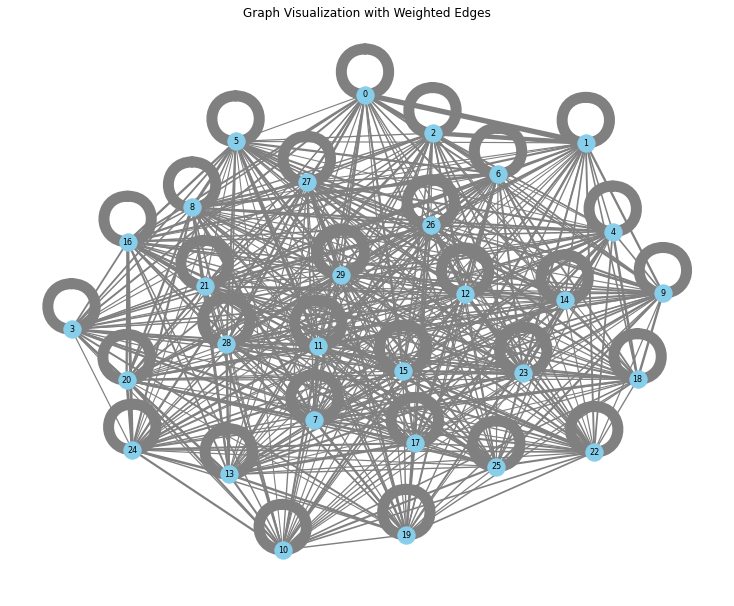

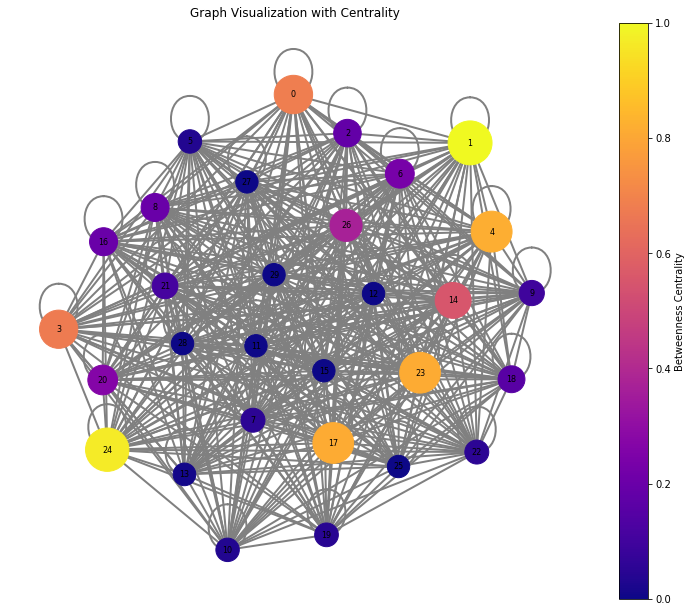

In [18]:


# Step 1: Use the test_subset graph for visualization
adj_matrix = test_subset.to_numpy()  # Assuming we are using the smaller subset
G = nx.from_numpy_array(adj_matrix)

# Step 2: Calculate betweenness centrality for nodes
centrality = nx.betweenness_centrality(G, weight='weight')

# Step 3: Node size and edge width based on centrality and weights
node_sizes = [500 + 5000 * centrality[node] for node in G.nodes]
edge_widths = [1 + 10 * G[u][v]['weight'] for u, v in G.edges]

# Step 4a: Plot the graph with weighted edges
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42)  # Spring layout for better visualization
nx.draw(
    G, pos,
    with_labels=True,
    node_size=300,
    node_color="skyblue",
    edge_color="gray",
    width=edge_widths,
    font_size=8
)
plt.title("Graph Visualization with Weighted Edges")
plt.show()

# Step 4b: Plot with node centrality
plt.figure(figsize=(10, 8))
nx.draw(
    G, pos,
    with_labels=True,
    node_size=node_sizes,
    node_color=list(centrality.values()),
    cmap=plt.cm.plasma,
    edge_color="gray",
    width=2,
    font_size=8
)
plt.colorbar(plt.cm.ScalarMappable(cmap=plt.cm.plasma), label="Betweenness Centrality")
plt.title("Graph Visualization with Centrality")
plt.show()


In [19]:
# Compute degree (number of edges for each node)
degree_dict = dict(G.degree(weight='weight'))

# Compute centrality of neighboring nodes
neighbor_centrality = {}
for node in G.nodes:
    neighbors = list(G.neighbors(node))
    neighbor_centrality[node] = sum(centrality[neighbor] for neighbor in neighbors)

# Create a DataFrame
df_summary = pd.DataFrame({
    'Node': list(G.nodes),
    'Centrality': [centrality[node] for node in G.nodes],
    'Degree': [degree_dict[node] for node in G.nodes],
    'Neighbor_Centrality': [neighbor_centrality[node] for node in G.nodes]
})

# Sort by centrality for better readability
df_summary = df_summary.sort_values(by='Centrality', ascending=False).reset_index(drop=True)

# Display the table
print(df_summary.head(10))  # Top 10 rows for example

# Save as a CSV (optional)
df_summary.to_csv("node_summary_first_30_muscle_to_muscle_regular_betweenness.csv", index=False)

   Node  Centrality    Degree  Neighbor_Centrality
0     1    0.285714  4.045163             2.384236
1    24    0.275862  3.841528             2.384236
2     4    0.233990  3.846202             2.384236
3    23    0.231527  3.990649             2.384236
4    17    0.231527  3.853760             2.384236
5     0    0.194581  4.022756             2.384236
6     3    0.192118  3.673826             2.384236
7    14    0.157635  3.800573             2.384236
8    26    0.105911  4.195725             2.384236
9    20    0.076355  3.940283             2.384236


In [20]:
#Min max scaling
from sklearn.preprocessing import MinMaxScaler

# Initialize the scaler
scaler = MinMaxScaler()

# Fit and transform the data
df_summary['Centrality_Scaled'] = scaler.fit_transform(df_summary[['Centrality']])
print(df_summary.head(10))  # Top 10 rows for example


   Node  Centrality    Degree  Neighbor_Centrality  Centrality_Scaled
0     1    0.285714  4.045163             2.384236           1.000000
1    24    0.275862  3.841528             2.384236           0.965517
2     4    0.233990  3.846202             2.384236           0.818966
3    23    0.231527  3.990649             2.384236           0.810345
4    17    0.231527  3.853760             2.384236           0.810345
5     0    0.194581  4.022756             2.384236           0.681034
6     3    0.192118  3.673826             2.384236           0.672414
7    14    0.157635  3.800573             2.384236           0.551724
8    26    0.105911  4.195725             2.384236           0.370690
9    20    0.076355  3.940283             2.384236           0.267241


In [ ]:
# Count the nodes with centrality greater than 0.02
nodes_with_high_centrality = sum(1 for value in centrality.values() if value > 0.07)

print(f"Number of nodes with centrality greater than 0.02: {nodes_with_high_centrality}")


In [11]:
subset_muscle_to_muscle = muscle_to_muscle.iloc[:200, :200]
subset_muscle_to_pancreas = muscle_to_pancreas.iloc[:200, :200]
subset_pancreas_to_muscle = pancreas_to_muscle.iloc[:200, :200]
subset_pancreas_to_pancreas = pancreas_to_pancreas.iloc[:200, :200]

# Step 3: Combine the blocks to create a 200x200 matrix
top_left = subset_muscle_to_muscle
top_right = subset_muscle_to_pancreas
bottom_left = subset_pancreas_to_muscle
bottom_right = subset_pancreas_to_pancreas

# Concatenate to form the 200x200 matrix
combined_matrix = pd.concat([pd.concat([top_left, top_right], axis=1), 
                             pd.concat([bottom_left, bottom_right], axis=1)], axis=0)

# Step 4: Show the new combined matrix
print(combined_matrix.shape)  # Should print (200, 200)
print(combined_matrix)

(400, 400)
            0         1         2         3         4         5         6  \
0    1.000000  0.432041  0.272557  0.098909  0.018232  0.011923  0.093101   
1    0.432041  1.000000  0.342903  0.004179  0.051786  0.014808  0.042831   
2    0.272557  0.342903  1.000000  0.017849  0.020318  0.028319  0.167359   
3    0.098909  0.004179  0.017849  1.000000  0.070137  0.083361  0.015539   
4    0.018232  0.051786  0.020318  0.070137  1.000000  0.005056  0.004922   
..        ...       ...       ...       ...       ...       ...       ...   
195  0.160509  0.103542  0.005339  0.099530  0.009268  0.025461  0.038234   
196  0.035862  0.048702  0.011948  0.038352  0.050863  0.048011  0.027851   
197  0.041559  0.132812  0.179085  0.002424  0.077524  0.027954  0.060787   
198  0.003928  0.001823  0.085314  0.005352  0.041499  0.005952  0.048733   
199  0.034009  0.041061  0.040555  0.016271  0.094052  0.043038  0.029063   

            7         8         9  ...      1180      1181      

In [12]:
import networkx as nx
import time

# Assuming `numeric_data` is your DataFrame
# Step 1: Create a graph from the entire numeric_data matrix
G_full = nx.from_numpy_array(combined_matrix.to_numpy())

# Step 2: Measure runtime for betweenness centrality calculation
start_time = time.time()

betweenness_full = nx.betweenness_centrality(G_full, weight='weight')

end_time = time.time()
runtime = end_time - start_time

# Step 3: Display results
print(f"Runtime for full {combined_matrix.shape[0]}x{combined_matrix.shape[1]} matrix: {runtime:.2f} seconds")
print("Sample betweenness centrality values:", dict(list(betweenness_full.items())))



Runtime for full 400x400 matrix: 64.70 seconds
Sample betweenness centrality values: {0: 0.01198977342854624, 1: 0.0011838641830707421, 2: 0.0024181055654210904, 3: 2.5188599639803025e-05, 4: 0.02423143285349051, 5: 0.02254379667762371, 6: 0.05336204833692271, 7: 0.009118273069608695, 8: 0.00013853729801891664, 9: 0.017216407853805366, 10: 0.02282087127366154, 11: 2.5188599639803025e-05, 12: 0.00013853729801891664, 13: 0.013627032405133436, 14: 0.004949559829221294, 15: 0.005843755116434302, 16: 0.0006171206911751741, 17: 0.010276948653039634, 18: 0.0028840946587574464, 19: 0.00035264039495724235, 20: 0.028463117592977417, 21: 0.01646074986461128, 22: 0.012052744927645747, 23: 0.0027203687610987265, 24: 0.00041561189405674994, 25: 0.0019269278724449313, 26: 0.022128184783566957, 27: 0.009130867369428596, 28: 0.00382866714525006, 29: 0.01950857042102744, 30: 0.00465989093336356, 31: 7.556579891940908e-05, 32: 0.0076699285903200215, 33: 0.009395347665646528, 34: 0.03300965982796186, 35: 

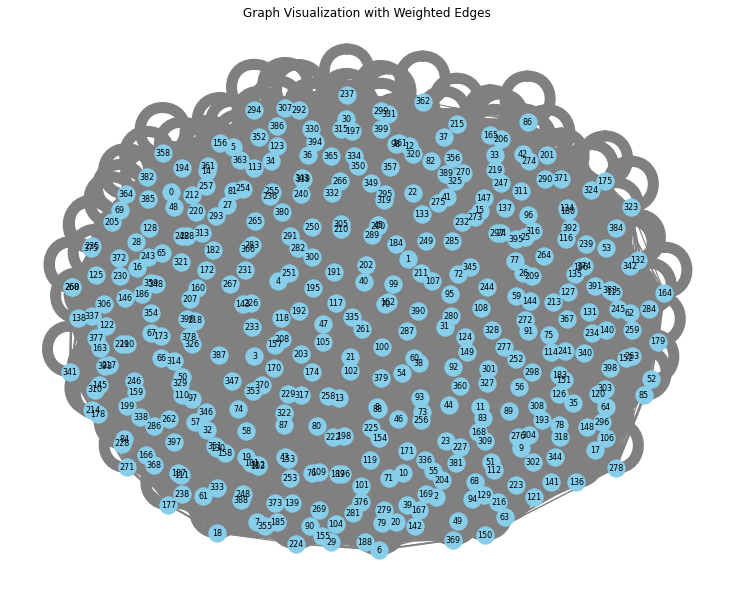

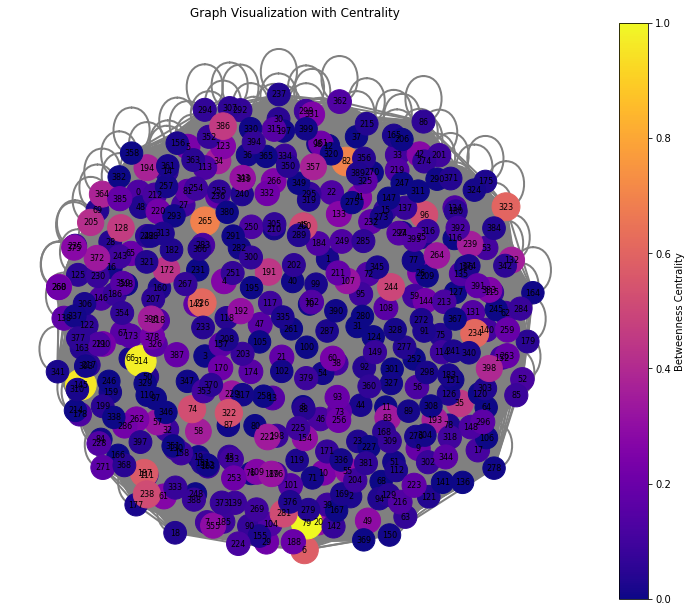

In [13]:


# Step 1: Use the test_subset graph for visualization
adj_matrix = combined_matrix.to_numpy()  # Assuming we are using the smaller subset
G = nx.from_numpy_array(combined_matrix.to_numpy())

# Step 2: Calculate betweenness centrality for nodes
centrality = betweenness_full
# Step 3: Node size and edge width based on centrality and weights
node_sizes = [500 + 5000 * centrality[node] for node in G.nodes]
edge_widths = [1 + 10 * G[u][v]['weight'] for u, v in G.edges]

# Step 4a: Plot the graph with weighted edges
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42)  # Spring layout for better visualization
nx.draw(
    G, pos,
    with_labels=True,
    node_size=300,
    node_color="skyblue",
    edge_color="gray",
    width=edge_widths,
    font_size=8
)
plt.title("Graph Visualization with Weighted Edges")
plt.show()

# Step 4b: Plot with node centrality
plt.figure(figsize=(10, 8))
nx.draw(
    G, pos,
    with_labels=True,
    node_size=node_sizes,
    node_color=list(centrality.values()),
    cmap=plt.cm.plasma,
    edge_color="gray",
    width=2,
    font_size=8
)
plt.colorbar(plt.cm.ScalarMappable(cmap=plt.cm.plasma), label="Betweenness Centrality")
plt.title("Graph Visualization with Centrality")
plt.show()


In [7]:
# Compute degree (number of edges for each node)
degree_dict = dict(G.degree(weight='weight'))

# Compute centrality of neighboring nodes
neighbor_centrality = {}
for node in G.nodes:
    neighbors = list(G.neighbors(node))
    neighbor_centrality[node] = sum(centrality[neighbor] for neighbor in neighbors)

# Create a DataFrame
df_summary = pd.DataFrame({
    'Node': list(G.nodes),
    'Centrality': [centrality[node] for node in G.nodes],
    'Degree': [degree_dict[node] for node in G.nodes],
    'Neighbor_Centrality': [neighbor_centrality[node] for node in G.nodes]
})

# Sort by centrality for better readability
df_summary = df_summary.sort_values(by='Centrality', ascending=False).reset_index(drop=True)

# Display the table
print(df_summary.head(10))  # Top 10 rows for example

# Save as a CSV (optional)
df_summary.to_csv("node_summary_first100_muscle_and_pancreas_centrality_data_betweenness.csv", index=False)

   Node  Centrality     Degree  Neighbor_Centrality
0   126    0.119537  13.280662             4.105528
1   197    0.104309  12.991465             4.105528
2    79    0.102837  13.376729             4.105528
3   122    0.085224  12.595655             4.105528
4    20    0.084158  11.937905             4.105528
5   123    0.082686  13.100504             4.105528
6     6    0.080300  12.500974             4.105528
7   111    0.075123  13.536132             4.105528
8   169    0.071367  12.435199             4.105528
9    82    0.071316  14.065785             4.105528


In [8]:
import networkx as nx

# Assuming G is your graph and betweenness centrality is calculated

# Calculate betweenness centrality
centrality = nx.betweenness_centrality(G, weight='weight')

# Identify high centrality nodes (nodes with high betweenness centrality)
threshold = 0.07  # Define a threshold for high centrality
high_central_nodes = [node for node, score in centrality.items() if score > threshold]

# Dictionary to store the contributing paths for high central nodes
contributing_paths = {node: [] for node in high_central_nodes}

# Step 1: Find all shortest paths
for source in G.nodes:
    for target in G.nodes:
        if source != target:
            # Find the shortest path between source and target
            try:
                shortest_path = nx.shortest_path(G, source=source, target=target, weight='weight')
                # Step 2: Track paths that pass through high central nodes
                for node in high_central_nodes:
                    if node in shortest_path and node != source and node != target:
                        contributing_paths[node].append(shortest_path)
            except nx.NetworkXNoPath:
                continue  # Skip if there's no path between source and target

# Step 3: Print the contributing paths for high centrality nodes
for node, paths in contributing_paths.items():
    print(f"Node {node} is part of {len(paths)} paths contributing to its centrality.")
    for path in paths:
        print("  Path:", path)


Node 6 is part of 3164 paths contributing to its centrality.
  Path: [0, 26, 195, 6, 56, 163, 181, 1]
  Path: [0, 26, 195, 6, 35, 55, 10]
  Path: [0, 26, 195, 6, 56, 163, 181, 160, 119, 12]
  Path: [0, 26, 195, 6, 35, 19]
  Path: [0, 26, 195, 6, 35]
  Path: [0, 26, 195, 6, 35, 55]
  Path: [0, 26, 195, 6, 56]
  Path: [0, 26, 195, 6, 100, 129, 164, 67]
  Path: [0, 26, 195, 6, 35, 55, 10, 74]
  Path: [0, 26, 195, 6, 78]
  Path: [0, 26, 195, 6, 100, 94, 86]
  Path: [0, 26, 195, 6, 100, 94]
  Path: [0, 26, 195, 6, 56, 163, 181, 160, 96]
  Path: [0, 26, 195, 6, 100]
  Path: [0, 26, 195, 6, 35, 55, 10, 74, 101]
  Path: [0, 26, 195, 6, 35, 19, 106]
  Path: [0, 26, 195, 6, 35, 55, 10, 74, 101, 109]
  Path: [0, 26, 195, 6, 35, 114]
  Path: [0, 26, 195, 6, 56, 163, 181, 160, 119]
  Path: [0, 26, 195, 6, 100, 129]
  Path: [0, 26, 195, 6, 56, 163, 181, 160]
  Path: [0, 26, 195, 6, 56, 163]
  Path: [0, 26, 195, 6, 100, 129, 164]
  Path: [0, 26, 195, 6, 56, 163, 181]
  Path: [0, 26, 195, 6, 100, 129,

In [9]:
# Assuming contributing_paths is already populated

# Specify the output file
output_file = "contributing_paths_top100_each_muscle_pancreas_betweenness_centrality.txt"

# Open the file in write mode
with open(output_file, "w") as f:
    for node, paths in contributing_paths.items():
        f.write(f"Node {node} is part of {len(paths)} paths contributing to its centrality.\n")
        for path in paths:
            f.write("  Path: " + " -> ".join(str(x) for x in path) + "\n")

print(f"Results written to {output_file}")


Results written to contributing_paths_top100_each_muscle_pancreas_betweenness_centrality.txt


In [10]:
# Specify the output file
output_file = "contributing_paths_top100_each_muscle_pancreas_betweenness_centrality_COUNT.txt"

# Open the file in write mode
with open(output_file, "w") as f:
    for node, paths in contributing_paths.items():
        f.write(f"Node {node} is part of {len(paths)} paths contributing to its centrality.\n")
        
        for path in paths:
            # Count muscle and pancreas nodes in the path
            muscle_count = sum(1 for n in path if 0 <= n < 100)  # Nodes in muscle (0-99)
            pancreas_count = sum(1 for n in path if 100 <= n < 200)  # Nodes in pancreas (100-199)
            
            f.write(f"  Path: {' -> '.join(str(x) for x in path)}\n")
            f.write(f"    Muscle nodes: {muscle_count}, Pancreas nodes: {pancreas_count}\n")

print(f"Results written to {output_file}")


Results written to contributing_paths_top100_each_muscle_pancreas_betweenness_centrality_COUNT.txt


In [ ]:
## Random Walk Centrality.